# Data split com Scikit-Learn

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


## Carregando os Dados

In [84]:
housing = pd.read_csv("datasets/housing/housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Scikit-Learning

In [85]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [86]:
train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14196,-117.22,32.75,34.0,6001.0,1111.0,2654.0,1072.0,4.5878,291000.0,NEAR OCEAN
8267,-117.03,32.69,10.0,901.0,163.0,698.0,167.0,4.6648,156100.0,NEAR OCEAN
17445,-122.27,37.74,28.0,6909.0,1554.0,2974.0,1484.0,3.6875,353900.0,NEAR BAY
14265,-121.82,37.25,25.0,4021.0,634.0,2178.0,650.0,5.1663,241200.0,<1H OCEAN
2271,-115.98,33.32,8.0,240.0,46.0,63.0,24.0,1.4688,53800.0,INLAND


In [87]:
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-122.38,40.67,10.0,2281.0,444.0,1274.0,438.0,2.2120,65600.0,INLAND
3024,-118.37,33.83,35.0,1207.0,207.0,601.0,213.0,4.7308,353400.0,<1H OCEAN
15663,-117.24,32.72,39.0,3089.0,431.0,1175.0,432.0,7.5925,466700.0,NEAR OCEAN
20484,-118.44,34.05,18.0,4780.0,1192.0,1886.0,1036.0,4.4674,500001.0,<1H OCEAN
9814,-118.44,34.18,33.0,2127.0,414.0,1056.0,391.0,4.3750,286100.0,<1H OCEAN


## Aleatoriedade vs Representatividade

Até então, consideramos métodos de amostragem unicamente aleatórios. Se o dataset for grande o suficiente ( principalmente contendo muitas *features* ) isso é bom mas, se não for, corremos o risco de introduzir um *viés de amostragem*. Então, em um dataset não tão grande, usar amostras exclusivamente aleatórias, aumenta a chance de perda de **representatividade**.

### Amostragem Estratificada

Para solucionar esse problema, usamos uma amostragem estratificada ( *stratified sampling* ):
<p align="center"><i>Divide a população em subgrupos homogêneos (estratos) e amostra proporcionalmente de cada um.</i></p>

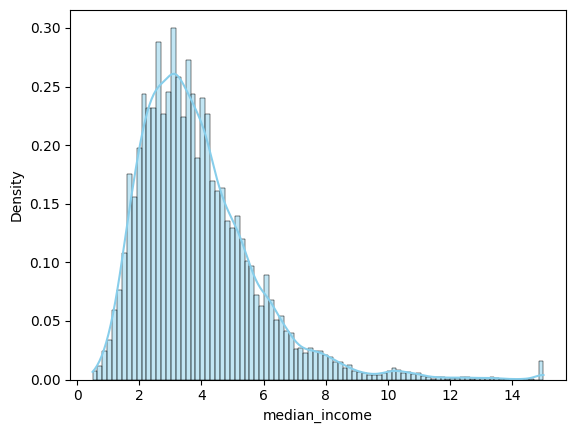

In [88]:
sns.histplot(housing['median_income'], kde=True, color='skyblue', stat="density")
plt.show()

Existe uma distribuição desigual na *feature* `median_income`.

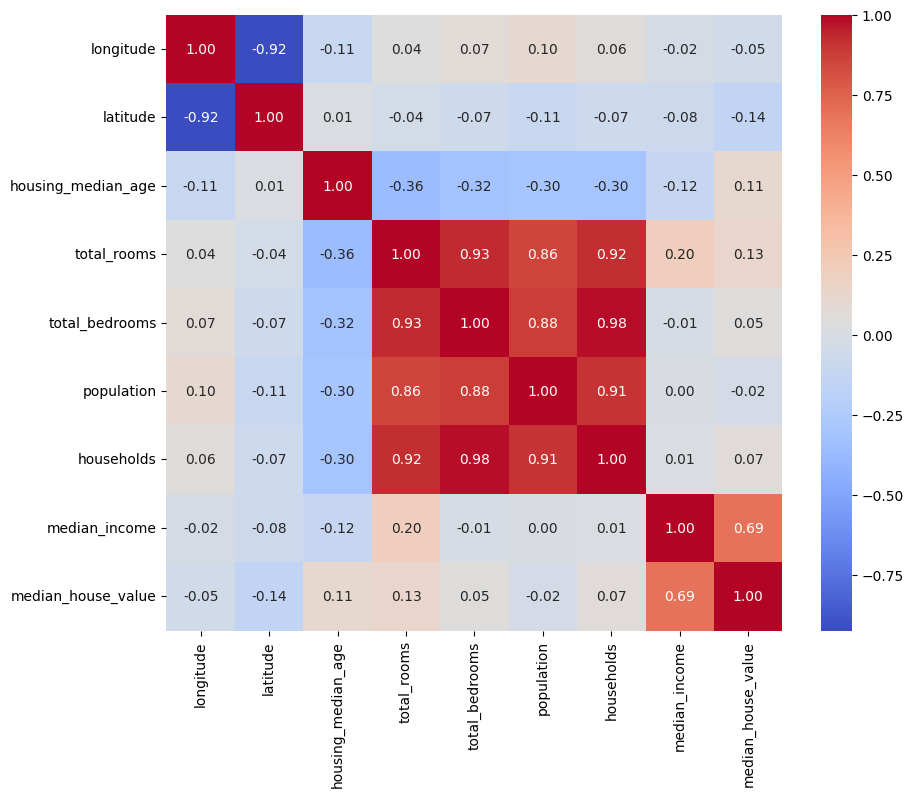

In [89]:
corr = housing.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.show()

Analisando a matriz de correlação, `median_income` é a *feature* mais correlacionada com o nosso *target* e, portanto, trata-se de um atributo muito importante para a previsão do preço.

Se você amostrar aleatoriamente e, por azar, a sua amostra tiver proporcionalmente:
- Muitos registros de renda alta
- Poucos registros de baixa renda

→ Seu modelo vai aprender com uma distribuição distorcida da realidade.

Então, como a correlação entre `median_house_value` e `median_income` são altas e o histograma revela uma distriubuição desigual desse último atributo, vamos usá-lo para estratificar a nossa amostra.

- Do histograma identificamos que a maioria dos valores médios está agrupado de 1.5 a 6, no entanto, alguns ultrapassam o 6.

- É importante ter um número suficiente de instâncias para cada estrato do seu conjunto se não a estimativa de estratos pode ser tendenciosa.

- Então, você não deve ter muitos estratos e cada estrato deve ser grande o bastante.

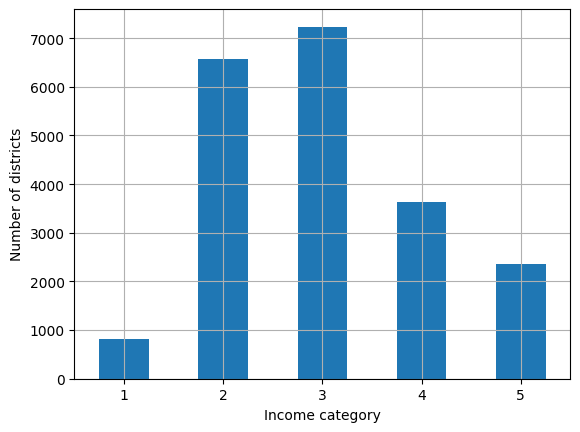

In [90]:
housing['income_cat'] = pd.cut(housing['median_income'], bins=[0., 1.5, 3.0, 4.5, 6, np.inf], labels=[1,2,3,4,5])

housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()


Agora podemos fazer uma amostragem estratificada com base na categoria de renda.

Vamos usar a classe `StratfiedShuffleSplit` do `Scikit-Learn`

In [91]:
from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42) #vamos criar 10 pares training/test
strat_splits = [] #lista de pares training/test

for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

``split`` recebe o dataset e a coluna de estratificação, e devolve índices das linhas separadas em treino e teste — respeitando as proporções de cada estrato.

Se quisermos apenas um conjunto `training/test` podemos usar:

In [92]:
strat_train_set, strat_test_set = strat_splits[0] #pega só o primeiro

ou usamos uma função pronta pra isso:

In [93]:
strat_train_set, strat_test_set = train_test_split(
housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

Vamos ver se funcionou como esperávamos (respeitando as proporcoes):

In [94]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

### Tabela comparativa das proporcoes geradas por amostragem Estratificada e Aleatória

In [95]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
import pandas as pd
import numpy as np

#criando coluna de categorias
housing["income_cat"] = pd.cut(housing["median_income"],
                                bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                labels=[1, 2, 3, 4, 5])

#amostragen puramente aleatoria
train_random, test_random = train_test_split(housing, 
                                              test_size=0.2, 
                                              random_state=42)

#amostragem estratificada
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in splitter.split(housing, housing["income_cat"]):
    train_strat = housing.iloc[train_idx]
    test_strat  = housing.iloc[test_idx]

#funcao p/ geracao das colunas de proporcao
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

tabela = pd.DataFrame({
    "Original"     : income_cat_proportions(housing),
    "Random"    : income_cat_proportions(test_random),
    "Stratified": income_cat_proportions(test_strat),
}).sort_index()

#erro percentual em relacao ao original
tabela["Rand. %error"]     = ((tabela["Random"]     / tabela["Original"]) - 1) * 100
tabela["Strat. %error"] = ((tabela["Stratified"] / tabela["Original"]) - 1) * 100

display(tabela.round(4))

,Original,Random,Stratified,Rand. %error,Strat. %error
income_cat,,,,,
1,0.0398,0.0424,0.0400,6.4477,0.3650
2,0.3188,0.3074,0.3188,-3.5861,-0.0152
3,0.3506,0.3452,0.3505,-1.5340,-0.0138
4,0.1763,0.1841,0.1764,4.4243,0.0275
5,0.1144,0.1209,0.1143,5.6308,-0.0847


Agora removeos a feature `income_cat` para que os dados voltem ao estado original:

In [96]:
#removendo income_cat dos conjuntos training/test
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)